# 04. PPO vs PPO-Lagrangian 학습 실습

논문의 핵심인 **PPO-Lagrangian(primal–dual)** 을 순수 PyTorch 로 간단히 구현하고, toy 환경에서 다섯 가지 설정을 학습해 비교합니다.

| 튜토리얼 변형 | 논문 설정 | 스위치 |
|---|---|---|
| `A1_Correction` | A1 | plain PPO, `constraint_types=2` |
| `A2_Penalty` | A2 | plain PPO, `constraint_types=3` |
| `A3_Lagrangian` | A3 | PPO-Lagrangian, `constraint_types=3` |
| `B3_FullMask` | B3 / C1 | A3 + enhanced mask |
| `C2_Square` | C2 | B3 + square mapping |

### PPO-Lagrangian 요약

제약 최적화 문제 $\max_\pi J_r(\pi)\ \text{s.t.}\ J_c(\pi) \le d$ 를 라그랑지안 $L(\pi,\lambda) = J_r(\pi) - \lambda (J_c(\pi) - d)$ 로 바꿉니다.

* **primal step (정책)**: PPO 의 클리핑 목적함수를 보상 어드밴티지 $A_r$ 대신 $\frac{A_r - \lambda A_c}{1+\lambda}$ 로 계산
* **dual step (승수)**: $\lambda \leftarrow \max\big(0,\ \lambda + \eta_\lambda (\hat J_c - d)\big)$ — 비용이 임계값 $d$ 를 넘으면 $\lambda$ 가 커져 페널티가 강해지고, 아래로 내려오면 다시 줄어듭니다.

설정 파일의 `policy.lagrangian` 블록이 바로 이 값들입니다: `constraint_threshold=d=0.05`, `learning_rate=η_λ=0.01`, `initial_penalty=λ₀=1.0`, `update_interval=4`(미니배치마다), `use_relu=True`(양의 위반만 반영).

In [1]:
import sys, time, copy, numpy as np, pandas as pd, matplotlib.pyplot as plt, torch, torch.nn as nn
sys.path.insert(0, ".")
import toy_reservoir as tr
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0); np.random.seed(0)
plt.rcParams["figure.figsize"] = (11, 3.4)
print("device:", device, "| torch", torch.__version__)

device: cuda | torch 2.11.0+cu128


## 1. 모델: 인코더를 공유하는 Actor–Critic

설정 파일의 `encoder_hidden_size_list=[512,512,256]` 구조를 따르되, 튜토리얼에서는 빠른 학습을 위해 크기를 줄입니다. PPO-Lagrangian 은 **비용(cost) 가치 헤드**를 하나 더 가집니다.

In [2]:
class ActorCritic(nn.Module):
    def __init__(self, obs_dim=6, n_actions=100, hidden=(128, 128, 64)):
        super().__init__()
        layers, d = [], obs_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU()]; d = h
        self.encoder = nn.Sequential(*layers)
        self.actor = nn.Sequential(nn.Linear(d, d), nn.ReLU(), nn.Linear(d, n_actions))
        self.critic_r = nn.Sequential(nn.Linear(d, d), nn.ReLU(), nn.Linear(d, 1))   # reward value
        self.critic_c = nn.Sequential(nn.Linear(d, d), nn.ReLU(), nn.Linear(d, 1))   # cost value (Lagrangian only)

    def forward(self, obs, mask=None):
        z = self.encoder(obs)
        logits = self.actor(z)
        if mask is not None:
            logits = logits.masked_fill(~mask, -1e9)       # action masking = zero probability
        return torch.distributions.Categorical(logits=logits), self.critic_r(z).squeeze(-1), self.critic_c(z).squeeze(-1)

## 2. 롤아웃 수집과 GAE

설정 파일처럼 `collector_env_num` 개의 환경에서 데이터를 모으고, 보상과 비용 각각에 대해 GAE(λ=0.95, γ=0.99)를 계산합니다.

In [3]:
def gae(rew, val, done, last_val, gamma=0.99, lam=0.95):
    T = len(rew); adv = np.zeros(T, np.float32); g = 0.0
    for t in reversed(range(T)):
        nv = last_val if t == T - 1 else val[t + 1]
        delta = rew[t] + gamma * nv * (1 - done[t]) - val[t]
        g = delta + gamma * lam * (1 - done[t]) * g
        adv[t] = g
    return adv, adv + val

@torch.no_grad()
def collect(model, envs, use_mask, seed):
    buf = {k: [] for k in ("obs", "mask", "act", "logp", "rew", "cost", "val_r", "val_c", "done")}
    ep_ret, ep_cost = [], []
    for i, env in enumerate(envs):
        obs, info = env.reset(seed=seed * 100 + i)
        rets, costs, done = 0.0, [], False
        while not done:
            mask = torch.as_tensor(info["action_mask"] if use_mask else np.ones(100, bool), device=device)
            o = torch.as_tensor(obs, device=device)
            dist, vr, vc = model(o, mask)
            a = dist.sample()
            obs2, r, te, tu, info = env.step(int(a)); done = te or tu
            c = info["constraint_cost_normalized"]
            for k, v in zip(buf, (obs, mask.cpu().numpy(), int(a), float(dist.log_prob(a)), r, c, float(vr), float(vc), float(done))):
                buf[k].append(v)
            obs = obs2; rets += r; costs.append(c)
        ep_ret.append(rets); ep_cost.append(np.mean(costs))
    b = {k: np.asarray(v) for k, v in buf.items()}
    b["adv_r"], b["ret_r"] = gae(b["rew"], b["val_r"], b["done"], 0.0)
    b["adv_c"], b["ret_c"] = gae(b["cost"], b["val_c"], b["done"], 0.0)
    return b, float(np.mean(ep_ret)), float(np.mean(ep_cost))

## 3. PPO / PPO-Lagrangian 업데이트

`lagrangian=False` 면 표준 PPO(A1, A2), `True` 면 primal–dual 업데이트(A3, B3, C2)입니다. 하이퍼파라미터 이름은 설정 파일과 같게 두었습니다.

In [4]:
def train(name, *, constraint_types=3, lagrangian=False, enable_action_mask=False, mask_rule_type="basic", mapping="linear",
          n_iters=40, collector_env_num=5, epoch_per_collect=10, batch_size=365, learning_rate=1e-3,
          clip_ratio=0.2, entropy_weight=0.016, value_weight=0.6,
          constraint_threshold=0.05, lag_lr=0.01, initial_penalty=1.0, update_interval=4, use_relu=True, seed=0, verbose=True):
    torch.manual_seed(seed); np.random.seed(seed)
    envs = [tr.ToyReservoirEnv(constraint_types, enable_action_mask, mask_rule_type, mapping, seed=seed * 10 + i) for i in range(collector_env_num)]
    model = ActorCritic().to(device); opt = torch.optim.Adam(model.parameters(), lr=learning_rate)
    lam = initial_penalty if lagrangian else 0.0
    hist, t0, mb_counter = [], time.time(), 0
    for it in range(n_iters):
        b, ep_ret, ep_cost = collect(model, envs, enable_action_mask, seed=it + 1000 * seed)
        T = len(b["rew"]); obs = torch.as_tensor(b["obs"], device=device); mask = torch.as_tensor(b["mask"], device=device)
        act = torch.as_tensor(b["act"], device=device); old_logp = torch.as_tensor(b["logp"], device=device)
        adv_r = torch.as_tensor(b["adv_r"], device=device); adv_c = torch.as_tensor(b["adv_c"], device=device)
        ret_r = torch.as_tensor(b["ret_r"], device=device); ret_c = torch.as_tensor(b["ret_c"], device=device)
        adv_r = (adv_r - adv_r.mean()) / (adv_r.std() + 1e-8)   # adv_norm=True
        if lagrangian:
            adv_c = (adv_c - adv_c.mean()) / (adv_c.std() + 1e-8)
        for _ in range(epoch_per_collect):
            for idx in torch.randperm(T, device=device).split(batch_size):
                dist, vr, vc = model(obs[idx], mask[idx])
                logp = dist.log_prob(act[idx]); ratio = torch.exp(logp - old_logp[idx])
                adv = (adv_r[idx] - lam * adv_c[idx]) / (1 + lam) if lagrangian else adv_r[idx]
                pg = -torch.min(ratio * adv, torch.clamp(ratio, 1 - clip_ratio, 1 + clip_ratio) * adv).mean()
                vloss = ((vr - ret_r[idx]) ** 2).mean() + (((vc - ret_c[idx]) ** 2).mean() if lagrangian else 0.0)
                loss = pg + value_weight * vloss - entropy_weight * dist.entropy().mean()
                opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 0.5); opt.step()
                # ---- dual step: update the multiplier every `update_interval` minibatches
                mb_counter += 1
                if lagrangian and mb_counter % update_interval == 0:
                    viol = ep_cost - constraint_threshold
                    if use_relu: viol = max(viol, 0.0) if viol > 0 else viol   # relu only affects the *growth*; still allow decay
                    lam = max(0.0, lam + lag_lr * viol)
        hist.append(dict(iter=it, episode_return=ep_ret, mean_cost=ep_cost, lam=lam))
        if verbose and (it % 10 == 0 or it == n_iters - 1):
            print(f"[{name}] iter {it:3d} | return {ep_ret:7.2f} | cost {ep_cost:.4f} | lambda {lam:.3f} | {time.time()-t0:5.0f}s")
    return model, pd.DataFrame(hist)

## 4. 다섯 변형 학습

`N_ITERS` 를 늘리면 더 수렴한 결과를 볼 수 있습니다 (40 iter ≈ 2–5분, CPU 기준).

In [5]:
N_ITERS = 40
VARIANTS = {
    "A1_Correction": dict(constraint_types=2, lagrangian=False),
    "A2_Penalty":    dict(constraint_types=3, lagrangian=False),
    "A3_Lagrangian": dict(constraint_types=3, lagrangian=True),
    "B3_FullMask":   dict(constraint_types=3, lagrangian=True, enable_action_mask=True, mask_rule_type="enhanced"),
    "C2_Square":     dict(constraint_types=3, lagrangian=True, enable_action_mask=True, mask_rule_type="enhanced", mapping="square"),
}
models, curves = {}, {}
for name, kw in VARIANTS.items():
    models[name], curves[name] = train(name, n_iters=N_ITERS, **kw)

[A1_Correction] iter   0 | return  170.36 | cost 0.1644 | lambda 0.000 |     3s


[A1_Correction] iter  10 | return  170.53 | cost 0.1706 | lambda 0.000 |    28s


[A1_Correction] iter  20 | return  180.42 | cost 0.1666 | lambda 0.000 |    51s


[A1_Correction] iter  30 | return  186.48 | cost 0.1622 | lambda 0.000 |    76s


[A1_Correction] iter  39 | return  189.30 | cost 0.1615 | lambda 0.000 |    97s


...

[C2_Square] iter   0 | return   10.66 | cost 0.0692 | lambda 1.002 |     2s


[C2_Square] iter  10 | return   -3.79 | cost 0.0754 | lambda 1.031 |    26s


[C2_Square] iter  20 | return   23.32 | cost 0.0633 | lambda 1.056 |    51s


[C2_Square] iter  30 | return   31.15 | cost 0.0597 | lambda 1.078 |    76s


[C2_Square] iter  39 | return   71.67 | cost 0.0402 | lambda 1.082 |   104s


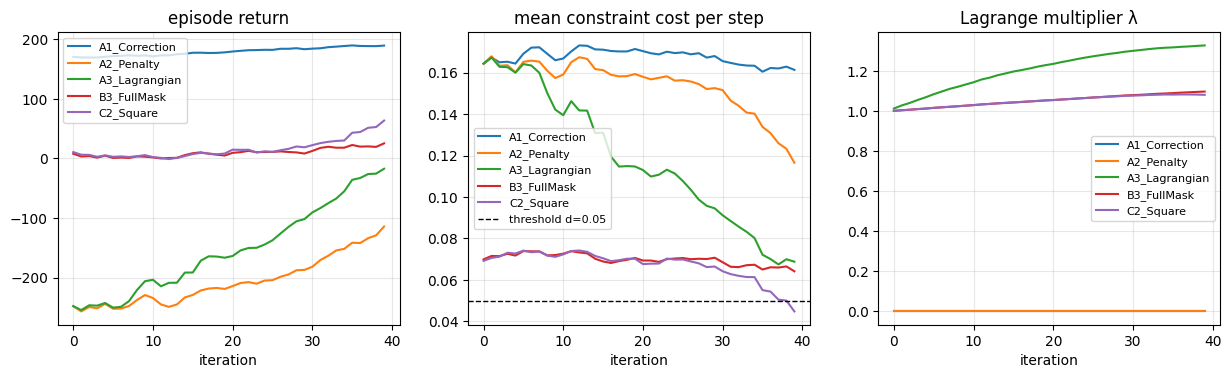

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for name, h in curves.items():
    axes[0].plot(h.iter, h.episode_return.rolling(3, min_periods=1).mean(), label=name)
    axes[1].plot(h.iter, h.mean_cost.rolling(3, min_periods=1).mean(), label=name)
    axes[2].plot(h.iter, h.lam, label=name)
axes[0].set_title("episode return"); axes[1].set_title("mean constraint cost per step"); axes[2].set_title("Lagrange multiplier λ")
axes[1].axhline(0.05, c="k", ls="--", lw=1, label="threshold d=0.05")
for a in axes: a.set_xlabel("iteration"); a.grid(alpha=.3); a.legend(fontsize=8)

**읽는 법**

* `A1_Correction` 은 페널티가 없으므로 보상은 높아 보이지만 비용은 줄어들지 않습니다. 환경이 대신 고쳐줄 뿐입니다.
* `A2_Penalty` 는 고정 페널티로 비용을 줄이지만, 페널티 크기를 사람이 정해야 하고 보상과의 균형이 고정됩니다.
* `A3_Lagrangian` 은 λ 가 자동으로 조정됩니다. 비용이 0.05 위에 있으면 λ 가 커지고, 아래로 내려오면 줄어듭니다.
* `B3_FullMask`, `C2_Square` 는 마스크 덕분에 처음부터 비용이 낮아 λ 가 크게 오르지 않고, 보상 학습에 집중합니다.

## 5. 학습된 정책의 운영 궤적 비교

같은 유입량 시나리오에 대해 각 정책이 만든 1년 수위·방류 궤적을 그립니다.

,variant,episode_return,mean_cost,energy_1e8kWh,eco_violation_days,flood_violation_days
0,A1_Correction,190.902,0.153,1030.872,77,122
1,A2_Penalty,-15.939,0.077,863.216,86,0
2,A3_Lagrangian,40.034,0.041,855.770,35,8
3,B3_FullMask,30.684,0.065,870.770,77,3
4,C2_Square,95.313,0.033,888.970,37,10


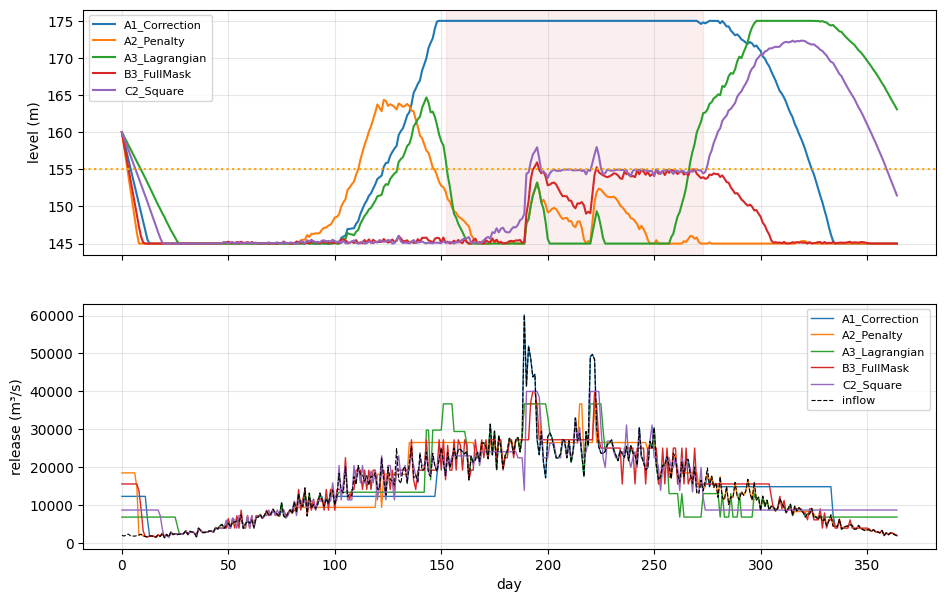

In [7]:
@torch.no_grad()
def greedy_policy(model, use_mask):
    def pol(obs, mask):
        m = torch.as_tensor(mask if use_mask else np.ones(100, bool), device=device)
        dist, _, _ = model(torch.as_tensor(obs, device=device), m)
        return int(dist.probs.argmax())
    return pol

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
eval_rows = []
for name, kw in VARIANTS.items():
    env = tr.ToyReservoirEnv(kw.get("constraint_types", 3), kw.get("enable_action_mask", False), kw.get("mask_rule_type", "basic"), kw.get("mapping", "linear"))
    log = tr.run_episode(env, greedy_policy(models[name], env.enable_action_mask), seed=2024, init_level=160)
    axes[0].plot(log.t, log.level, label=name); axes[1].plot(log.t, log.release, label=name, lw=1)
    eval_rows.append(dict(variant=name, episode_return=log.reward.sum(), mean_cost=log.constraint_cost.mean(), energy_1e8kWh=log.energy.sum(),
                          eco_violation_days=int((log.cost_ecological > 0).sum()), flood_violation_days=int((log.cost_flood > 0).sum())))
axes[0].axhline(tr.Z_FLOOD_LIMIT, c="orange", ls=":"); axes[0].axvspan(*tr.FLOOD_SEASON, color="tab:red", alpha=.08); axes[0].set_ylabel("level (m)"); axes[0].legend(fontsize=8)
axes[1].plot(log.t, log.inflow, c="k", lw=.8, ls="--", label="inflow"); axes[1].set_ylabel("release (m³/s)"); axes[1].set_xlabel("day"); axes[1].legend(fontsize=8)
for a in axes: a.grid(alpha=.3)
pd.DataFrame(eval_rows).round(3)

## 정리

* PPO-Lagrangian 은 페널티 계수를 **학습 중에 자동으로 조정**하는 것이 핵심이며, 설정 파일의 `policy.lagrangian` 블록 6개 값으로 완전히 기술됩니다.
* 논문의 2-layer 프레임워크 = (1) 액션 마스크 안전층 + (2) Lagrangian 쌍대 최적화. 이 노트북의 `B3_FullMask` 가 그 조합입니다.
* 실제 논문 실험은 4년 × 300 에피소드, 512-512-256 네트워크, 실측 유입량으로 진행되었습니다. 여기서의 수치는 메커니즘 이해용입니다.

### 더 해볼 것
* `N_ITERS` 를 200 이상으로 늘려 수렴 비교
* `constraint_threshold`, `lag_lr` 를 바꿔 λ 의 반응 관찰
* `mapping` 을 `sqrt`, `exp`, `log` 로 바꿔 실험 C 재현